## Load and Compare Metacell Sizes\n\nQuick comparison of merged splice anndatas across metacell sizes:
- SpliceVI (default, ~9711 metacells)
- SpliceVI_500 (14,171 metacells)
- SpliceVI_1000 (8,383 metacells)
- SpliceVI_2000 (4,908 metacells)
- SpliceVI_4000 (3,142 metacells)

In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.sparse import issparse

In [2]:
base = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells"

paths = {
    "default": f"{base}/SpliceVI/20260210/RH/ATSEmap/junction_processing_20260213/anndatas/merged_anndata.h5ad",
    "500": f"{base}/SpliceVI_500/ATSEmap/junction_processing_20260318/anndatas/merged_anndata.h5ad",
    "1000": f"{base}/SpliceVI_1000/ATSEmap/junction_processing_20260318/anndatas/merged_anndata.h5ad",
    "2000": f"{base}/SpliceVI_2000/ATSEmap/junction_processing_20260318/anndatas/merged_anndata.h5ad",
    "4000": f"{base}/SpliceVI_4000/ATSEmap/junction_processing_20260318/anndatas/merged_anndata.h5ad",
}

adatas = {}
for name, path in paths.items():
    print(f"Loading {name}...")
    adatas[name] = ad.read_h5ad(path)
    print(f"  {name}: {adatas[name].shape[0]} cells x {adatas[name].shape[1]} features")

Loading default...
  default: 4931 cells x 69402 features
Loading 500...
  500: 14171 cells x 69277 features
Loading 1000...
  1000: 8383 cells x 69366 features
Loading 2000...
  2000: 4908 cells x 69401 features
Loading 4000...
  4000: 3142 cells x 69468 features


## Summary Table

In [3]:
summary_rows = []
for name, adata in adatas.items():
    # Get junction and ATSE counts from var
    n_junctions = adata.n_vars
    n_atses = adata.var["event_id"].nunique() if "event_id" in adata.var.columns else np.nan
    
    # Sparsity: fraction of zeros in cell_by_junction_matrix
    mat = adata.layers.get("cell_by_junction_matrix", adata.X)
    if issparse(mat):
        nnz = mat.nnz
        total = mat.shape[0] * mat.shape[1]
    else:
        nnz = np.count_nonzero(mat)
        total = mat.size
    sparsity = 1 - (nnz / total)
    
    # Mean reads per cell
    if issparse(mat):
        reads_per_cell = np.array(mat.sum(axis=1)).flatten()
    else:
        reads_per_cell = mat.sum(axis=1)
    
    # Cell types
    ct_col = "Main_cluster_name" if "Main_cluster_name" in adata.obs.columns else None
    n_celltypes = adata.obs[ct_col].nunique() if ct_col else np.nan
    
    summary_rows.append({
        "metacell_size": name,
        "n_metacells": adata.n_obs,
        "n_junctions": n_junctions,
        "n_ATSEs": n_atses,
        "sparsity": f"{sparsity:.3f}",
        "mean_reads_per_cell": f"{reads_per_cell.mean():.1f}",
        "median_reads_per_cell": f"{np.median(reads_per_cell):.1f}",
        "n_cell_types": n_celltypes,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,metacell_size,n_metacells,n_junctions,n_ATSEs,sparsity,mean_reads_per_cell,median_reads_per_cell,n_cell_types
0,default,4931,69402,26712,0.954,1565.7,542.0,31
1,500,14171,69277,26706,0.981,532.0,225.0,9
2,1000,8383,69366,26711,0.970,911.4,348.0,8
3,2000,4908,69401,26716,0.954,1573.0,540.0,32
4,4000,3142,69468,26727,0.938,2482.8,571.0,12


## Reads per Metacell Distribution

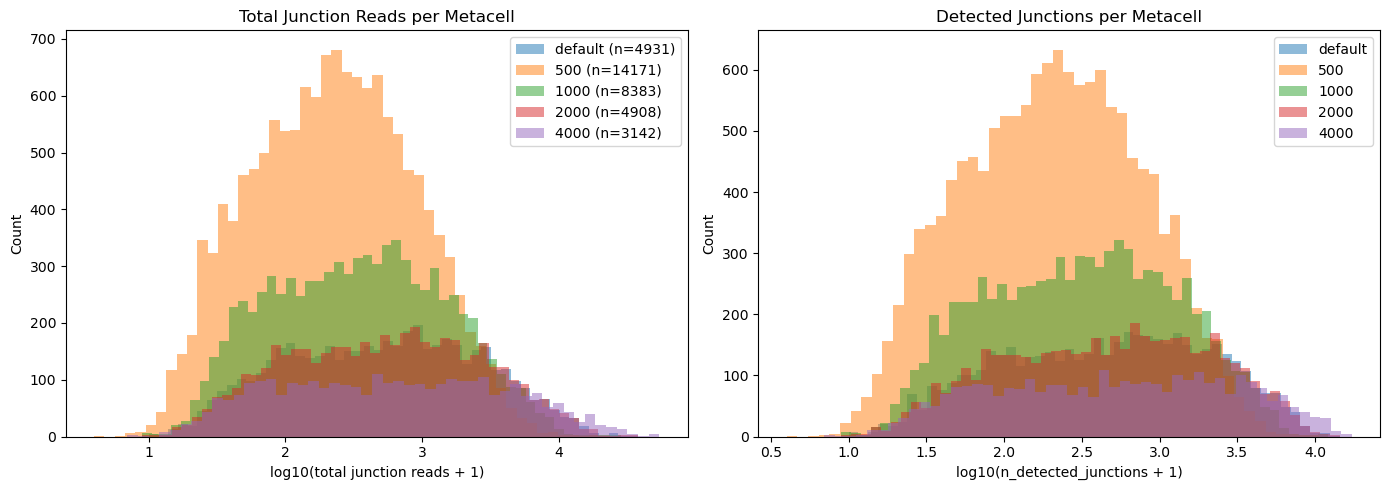

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of total reads per metacell
ax = axes[0]
for name, adata in adatas.items():
    mat = adata.layers.get("cell_by_junction_matrix", adata.X)
    if issparse(mat):
        reads = np.array(mat.sum(axis=1)).flatten()
    else:
        reads = mat.sum(axis=1)
    ax.hist(np.log10(reads + 1), bins=50, alpha=0.5, label=f"{name} (n={adata.n_obs})")
ax.set_xlabel("log10(total junction reads + 1)")
ax.set_ylabel("Count")
ax.set_title("Total Junction Reads per Metacell")
ax.legend()

# Plot 2: Number of detected junctions per metacell
ax = axes[1]
for name, adata in adatas.items():
    mat = adata.layers.get("cell_by_junction_matrix", adata.X)
    if issparse(mat):
        n_detected = np.array((mat > 0).sum(axis=1)).flatten()
    else:
        n_detected = (mat > 0).sum(axis=1)
    ax.hist(np.log10(n_detected + 1), bins=50, alpha=0.5, label=f"{name}")
ax.set_xlabel("log10(n_detected_junctions + 1)")
ax.set_ylabel("Count")
ax.set_title("Detected Junctions per Metacell")
ax.legend()

plt.tight_layout()
plt.show()

## Sparsity vs Metacell Size

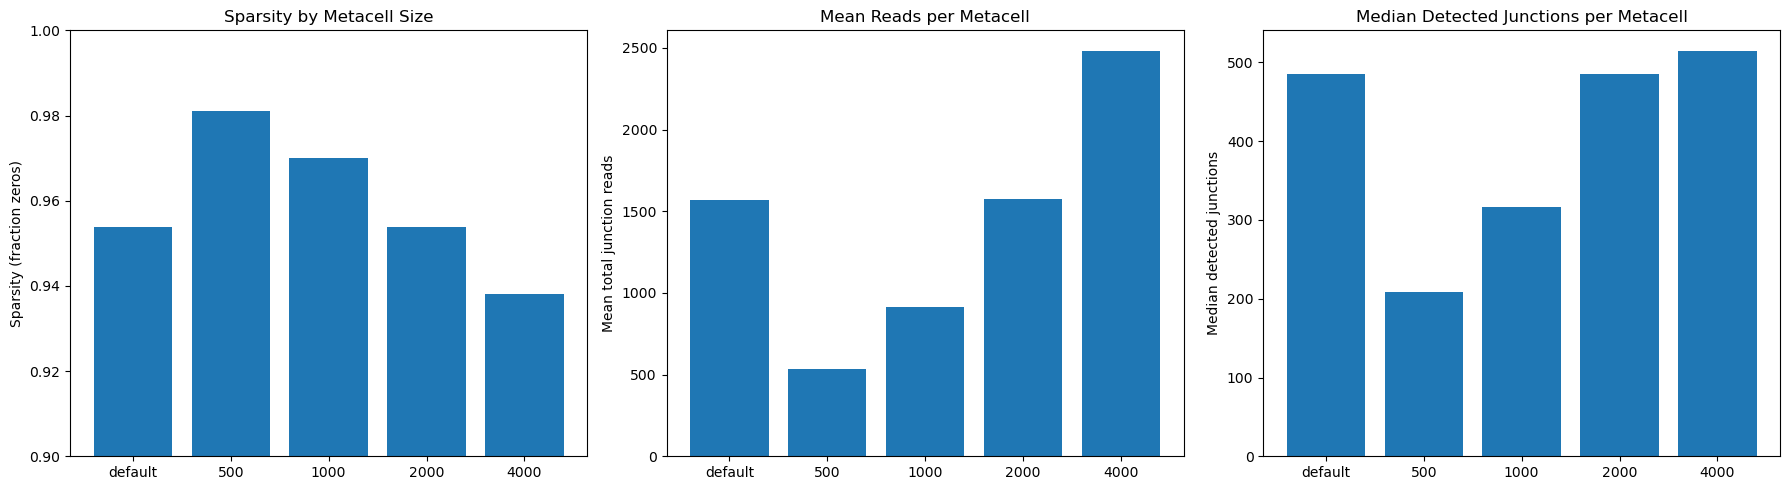

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sizes = []
sparsities = []
mean_reads = []
median_detected = []
labels = []

for name, adata in adatas.items():
    mat = adata.layers.get("cell_by_junction_matrix", adata.X)
    if issparse(mat):
        sp = 1 - (mat.nnz / (mat.shape[0] * mat.shape[1]))
        reads = np.array(mat.sum(axis=1)).flatten()
        detected = np.array((mat > 0).sum(axis=1)).flatten()
    else:
        sp = 1 - (np.count_nonzero(mat) / mat.size)
        reads = mat.sum(axis=1)
        detected = (mat > 0).sum(axis=1)
    
    sizes.append(adata.n_obs)
    sparsities.append(sp)
    mean_reads.append(reads.mean())
    median_detected.append(np.median(detected))
    labels.append(name)

# Sparsity
ax = axes[0]
ax.bar(labels, sparsities)
ax.set_ylabel("Sparsity (fraction zeros)")
ax.set_title("Sparsity by Metacell Size")
ax.set_ylim(0.9, 1.0)

# Mean reads
ax = axes[1]
ax.bar(labels, mean_reads)
ax.set_ylabel("Mean total junction reads")
ax.set_title("Mean Reads per Metacell")

# Median detected junctions
ax = axes[2]
ax.bar(labels, median_detected)
ax.set_ylabel("Median detected junctions")
ax.set_title("Median Detected Junctions per Metacell")

plt.tight_layout()
plt.show()

## Cell Type Breakdown per Metacell Size

In [6]:
ct_col = "Main_cluster_name"

ct_counts = {}
for name, adata in adatas.items():
    if ct_col in adata.obs.columns:
        ct_counts[name] = adata.obs[ct_col].value_counts()

ct_df = pd.DataFrame(ct_counts).fillna(0).astype(int)
ct_df["total"] = ct_df.sum(axis=1)
ct_df = ct_df.sort_values("total", ascending=False)
ct_df

,default,500,1000,2000,4000,total
Main_cluster_name,,,,,,
,0,13603,7623,76,2573,23875
Cerebellum_granule_neurons,1038,300,324,1021,197,2880
Interbrain_and_midbrain_neurons_1,1005,89,210,986,188,2478
Interbrain_and_midbrain_neurons_2,582,78,99,565,72,1396
Cortical_projection_neurons_1,520,49,96,506,60,1231
Oligodendrocytes,290,19,10,290,20,629
Astrocytes,224,13,10,223,10,480
OB_neurons_1,166,0,11,164,1,342
Striatal_neurons_1,143,0,0,137,10,290


## ATSE Overlap Across Metacell Sizes

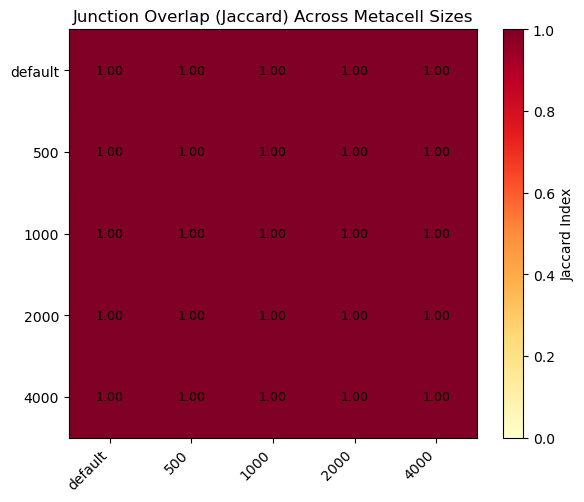


Junction counts per metacell size:
  default: 69402 junctions
  500: 69277 junctions
  1000: 69366 junctions
  2000: 69401 junctions
  4000: 69468 junctions


In [7]:
# Compare junction overlap between metacell sizes
junction_sets = {}
for name, adata in adatas.items():
    if "junction_id" in adata.var.columns:
        junction_sets[name] = set(adata.var["junction_id"].astype(str).values)

# Pairwise overlap matrix
names = list(junction_sets.keys())
overlap_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        overlap = len(junction_sets[n1] & junction_sets[n2])
        overlap_matrix.loc[n1, n2] = overlap / len(junction_sets[n1] | junction_sets[n2])  # Jaccard

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(overlap_matrix.values.astype(float), cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{float(overlap_matrix.iloc[i, j]):.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, label="Jaccard Index")
ax.set_title("Junction Overlap (Jaccard) Across Metacell Sizes")
plt.tight_layout()
plt.show()

# Print absolute counts
print("\nJunction counts per metacell size:")
for name, jset in junction_sets.items():
    print(f"  {name}: {len(jset)} junctions")